In [38]:
import pandas as pd
import numpy as np

from matplotlib import pyplot as plt
import seaborn as sns
import copy
import pickle
import shap
from models import *
from utilities import *
import warnings
warnings.filterwarnings('ignore')

In [39]:
##########################################################################################################

In [40]:
import tensorflow as tf
plt.rcParams['font.family'] = "Nimbus Sans"

In [41]:
# shap.explainers._deep.deep_tf.op_handlers["AddV2"] = shap.explainers._deep.deep_tf.passthrough 
# shap.explainers._deep.deep_tf.op_handlers["FusedBatchNormV3"] = shap.explainers._deep.deep_tf.passthrough

In [42]:
################### data import ###############

In [43]:
data_dir = '../results/data/'
data_copy = pd.read_pickle(data_dir + 'LSTM_processed_data_dy_filter.pkl')
ba_copy = pd.read_pickle(data_dir + 'LSTM_processed_data_ba_filter.pkl')
data_copy['Id_encoded'], uniques = pd.factorize(data_copy['SCCRIP_ID'])
data_copy = data_copy.fillna(0)
mapping_dict = {value: index for index, value in enumerate(uniques)}

In [44]:
hu = read_sas('../data/Apply_MI_Zheng_2023_01/hu.sas7bdat')

In [45]:
data_copy_nohu = data_copy[data_copy['HU_status']==0]
data_copy_hu = data_copy[data_copy['HU_status']!=0]

In [46]:
ba_copy['Id_encoded'] = ba_copy['SCCRIP_ID'].map(mapping_dict)
ba_copy = ba_copy[ba_copy['Id_encoded'].notna()]
ba_copy = ba_copy.drop_duplicates(subset='SCCRIP_ID', keep='last')
ba_copy.drop('SCCRIP_ID', inplace=True, axis=1)
ba_copy = ba_copy.fillna(0)

In [47]:
feature_dy = data_copy_nohu.drop(['HU_status','Id_encoded','SCCRIP_ID'],axis=1).columns
feature_ba = ba_copy.drop(['Id_encoded'], axis=1).columns

In [48]:
####################################################

In [49]:
seq_length = 5
r = 100

In [50]:
################# All
sequences, seq_ba, labels, date,  y_target = create_dataset(data_copy, ba_copy, seq_length, mapping_dict)
sequences_copy, seq_ba_copy, labels_copy, date_copy, y_target_copy = shuffle_dataset(sequences, seq_ba, labels, date, y_target)
X, y, X_bg, dt, ls_all, seq_map = create_sequences_with_background(sequences_copy, labels_copy, seq_ba_copy, date_copy,y_target_copy, seq_length)
X_normalized_all, X_bg_normalized_all = normalize_X(X, X_bg)
dt_all = dt.reshape(-1, 1, 1)

In [51]:
df = pd.DataFrame(ls_all, columns=['hus','id', 'age','date'])
df['test'] = y

In [52]:
#######################################

In [53]:
df_c = pd.DataFrame(ls_all, columns=['hus','id', 'age','date'])
df_t = pd.DataFrame(ls_all, columns=['hus','id', 'age','date'])

train_c = []
train_t = []

In [54]:
############ HU, T model
i = 0
r2hu_list = []
while i < r:
    sequences, seq_ba, labels, date,  y_target = create_dataset(data_copy_hu, ba_copy, seq_length, mapping_dict)
    sequences_copy_h, seq_ba_copy, labels_copy, date_copy, y_target_copy = shuffle_dataset(sequences, seq_ba, labels, date, y_target)
    X, y, X_bg, dt, ls, seq_map = create_sequences_with_background(sequences_copy_h, labels_copy, seq_ba_copy, date_copy,y_target_copy, seq_length)
    X_normalized, X_bg_normalized = normalize_X(X, X_bg)
    
    (X_train_hu,X_val_hu,X_test_hu,
                X_bg_train_hu,X_bg_val_hu,X_bg_test_hu,
                dt_train_hu, dt_val_hu, dt_test_hu, 
                y_train_hu,y_val_hu,y_test_hu,
                ls_train_hu, ls_val_hu, ls_test_hu,
                seq_map_train_hu, seq_map_val_hu, seq_map_test_hu) = split_dataset(X_normalized, X_bg_normalized,dt, y, ls, seq_map)
    
    T_model = CombinedLSTMModel(seq_length=seq_length, n_features=int(X_train_hu.shape[2]), bg_features=int(X_bg_train_hu.shape[2]), summary=False)

    history_T = T_model.train(
        X_train_hu, X_bg_train_hu, dt_train_hu, y_train_hu,
        X_val_hu,   X_bg_val_hu,   dt_val_hu,   y_val_hu,
        epochs=20, batch_size=64,verbose=0,
        checkpoint_path="../results/models/T_temp.h5")
    y_pred_hu = T_model.predict(X_test_hu, X_bg_test_hu, dt_test_hu)
    r2_hu = r2_score(y_test_hu.flatten(), y_pred_hu.flatten())
    if r2_hu > 0.8:
        y_treat = T_model.predict(X_normalized_all, X_bg_normalized_all, dt_all)
        df_t[i] = copy.deepcopy(y_treat)
        train_df = pd.DataFrame(ls_train_hu, columns=['hus','id', 'age','date'])
        val_df = pd.DataFrame(ls_val_hu, columns=['hus','id', 'age','date'])
        train_t.append(copy.deepcopy([train_df, val_df]))
        r2hu_list.append(r2_hu)
        i += 1


Epoch 1: val_loss improved from inf to 20.65439, saving model to ../results/models/T_temp.h5

Epoch 2: val_loss improved from 20.65439 to 17.20808, saving model to ../results/models/T_temp.h5

Epoch 3: val_loss did not improve from 17.20808

Epoch 4: val_loss improved from 17.20808 to 14.32546, saving model to ../results/models/T_temp.h5

Epoch 5: val_loss did not improve from 14.32546

Epoch 6: val_loss did not improve from 14.32546

Epoch 7: val_loss did not improve from 14.32546

Epoch 8: val_loss improved from 14.32546 to 13.53919, saving model to ../results/models/T_temp.h5

Epoch 9: val_loss did not improve from 13.53919

Epoch 10: val_loss did not improve from 13.53919

Epoch 11: val_loss did not improve from 13.53919

Epoch 12: val_loss did not improve from 13.53919

Epoch 13: val_loss did not improve from 13.53919

Epoch 14: val_loss did not improve from 13.53919

Epoch 15: val_loss did not improve from 13.53919

Epoch 16: val_loss did not improve from 13.53919

Epoch 17: val

In [55]:
############ no-HU C model
i = 0
r2nohu_list = []
while i < r:
    sequences, seq_ba, labels, date,  y_target = create_dataset(data_copy_nohu, ba_copy, seq_length, mapping_dict)
    sequences_copy, seq_ba_copy, labels_copy, date_copy, y_target_copy = shuffle_dataset(sequences, seq_ba, labels, date, y_target)
    X, y, X_bg, dt, ls, seq_map = create_sequences_with_background(sequences_copy, labels_copy, seq_ba_copy, date_copy,y_target_copy, seq_length)
    X_normalized, X_bg_normalized = normalize_X(X, X_bg)
    
    (X_train_nohu,X_val_nohu,X_test_nohu,
                X_bg_train_nohu,X_bg_val_nohu,X_bg_test_nohu,
                dt_train_nohu, dt_val_nohu, dt_test_nohu, 
                y_train_nohu,y_val_nohu,y_test_nohu,
                ls_train_nohu, ls_val_nohu, ls_test_nohu,
                seq_map_train_nohu, seq_map_val_nohu, seq_map_test_nohu) = split_dataset(X_normalized, X_bg_normalized,dt, y, ls, seq_map)
    
    C_model = CombinedLSTMModel(seq_length=seq_length, n_features=int(X_train_nohu.shape[2]), bg_features=int(X_bg_train_nohu.shape[2]), summary=False)

    history_C = C_model.train(
        X_train_nohu, X_bg_train_nohu, dt_train_nohu, y_train_nohu,
        X_val_nohu,   X_bg_val_nohu,   dt_val_nohu,   y_val_nohu,
        epochs=20, batch_size=64,verbose=0,
        checkpoint_path="../results/models/C_temp.h5")
    y_pred_nohu = C_model.predict(X_test_nohu, X_bg_test_nohu, dt_test_nohu)
    r2_nohu = r2_score(y_test_nohu.flatten(), y_pred_nohu.flatten())
    if r2_nohu > 0.75:
        y_con = C_model.predict(X_normalized_all, X_bg_normalized_all, dt_all)
        df_c[i] = copy.deepcopy(y_con)
        train_df = pd.DataFrame(ls_train_nohu, columns=['hus','id', 'age','date'])
        val_df = pd.DataFrame(ls_val_nohu, columns=['hus','id', 'age','date'])
        train_c.append(copy.deepcopy([train_df, val_df]))
        r2nohu_list.append(r2_nohu)
        i += 1


Epoch 1: val_loss improved from inf to 61.17434, saving model to ../results/models/C_temp.h5

Epoch 2: val_loss improved from 61.17434 to 56.41825, saving model to ../results/models/C_temp.h5

Epoch 3: val_loss improved from 56.41825 to 29.47940, saving model to ../results/models/C_temp.h5

Epoch 4: val_loss did not improve from 29.47940

Epoch 5: val_loss did not improve from 29.47940

Epoch 6: val_loss improved from 29.47940 to 18.69357, saving model to ../results/models/C_temp.h5

Epoch 7: val_loss did not improve from 18.69357

Epoch 8: val_loss did not improve from 18.69357

Epoch 9: val_loss did not improve from 18.69357

Epoch 10: val_loss did not improve from 18.69357

Epoch 11: val_loss did not improve from 18.69357

Epoch 12: val_loss improved from 18.69357 to 18.36769, saving model to ../results/models/C_temp.h5

Epoch 13: val_loss improved from 18.36769 to 11.84558, saving model to ../results/models/C_temp.h5

Epoch 14: val_loss did not improve from 11.84558

Epoch 15: val

In [56]:
df_t.to_pickle('../results/data/T_prediction_50.pkl')

df_c.to_pickle('../results/data/C_prediction_50.pkl')

In [57]:
with open ('../results/data/T_train_val_label_50.pkl', 'wb') as f:
    pickle.dump(train_t, f)

with open ('../results/data/C_train_val_label_50.pkl', 'wb') as f:
    pickle.dump(train_c, f)

In [58]:
with open ('../results/data/r2hu_50.pkl', 'wb') as f:
    pickle.dump(r2hu_list, f)

with open ('../results/data/r2nohu_50.pkl', 'wb') as f:
    pickle.dump(r2nohu_list, f)

In [59]:
######################################################

In [60]:
df_t = pd.read_pickle('../results/data/T_prediction_50.pkl')
df_c = pd.read_pickle('../results/data/C_prediction_50.pkl')

In [61]:
df_c.shape, df_t.shape

((29265, 104), (29265, 104))

In [62]:
# df = pd.read_pickle('../results/data/all_treat_control_prediction_loop_50.pkl')
# df = df[['hus','id', 'age','date','test']]

In [63]:
with open ('../results/data/T_train_val_label_50.pkl', 'rb') as f:
    train_t = pickle.load(f)

with open ('../results/data/C_train_val_label_50.pkl', 'rb') as f:
    train_c = pickle.load(f)

In [64]:
with open ('../results/data/r2hu_50.pkl', 'rb') as f:
    r2hu_list = pickle.load(f)

with open ('../results/data/r2nohu_50.pkl', 'rb') as f:
    r2nohu_list = pickle.load(f)

In [65]:
hu_indices = [i for i, x in enumerate(r2hu_list) if x < 0.80]
nohu_indices = [i for i, x in enumerate(r2nohu_list) if x < 0.75]


df_c = df_c.drop(columns=nohu_indices)
df_t = df_t.drop(columns=hu_indices)

df_c.shape, df_t.shape

((29265, 104), (29265, 104))

In [66]:
cols = ['hus','id', 'age','date']

main_idx_t = df_t.set_index(cols).index
for i in range(len(train_t)):
    t, v = train_t[i]
    mask_1 = main_idx_t.isin(t.set_index(cols).index)
    mask_2 = main_idx_t.isin(v.set_index(cols).index)
    combined_mask = mask_1 | mask_2
    df_t.loc[combined_mask, i] = np.nan

main_idx_c = df_c.set_index(cols).index
for i in range(len(train_c)):
    t, v = train_c[i]
    mask_1 = main_idx_c.isin(t.set_index(cols).index)
    mask_2 = main_idx_c.isin(v.set_index(cols).index)
    combined_mask = mask_1 | mask_2
    df_c.loc[combined_mask, i] = np.nan

In [67]:
df_c["pred_c"] = df_c.iloc[:, 4:].mean(axis=1,skipna=True)
df_t["pred_t"] = df_t.iloc[:, 4:].mean(axis=1,skipna=True)

In [68]:
c = df_c[['hus','id','age', 'date', "pred_c"]]
t = df_t[['hus','id','age', 'date', "pred_t"]]

In [69]:
c["date"] = pd.to_datetime(c["date"])
t["date"] = pd.to_datetime(t["date"])
df["date"] = pd.to_datetime(df["date"])
df = df.merge(c, on=['hus','id','age', 'date'], how='left')
df = df.merge(t, on=['hus','id','age', 'date'], how='left')

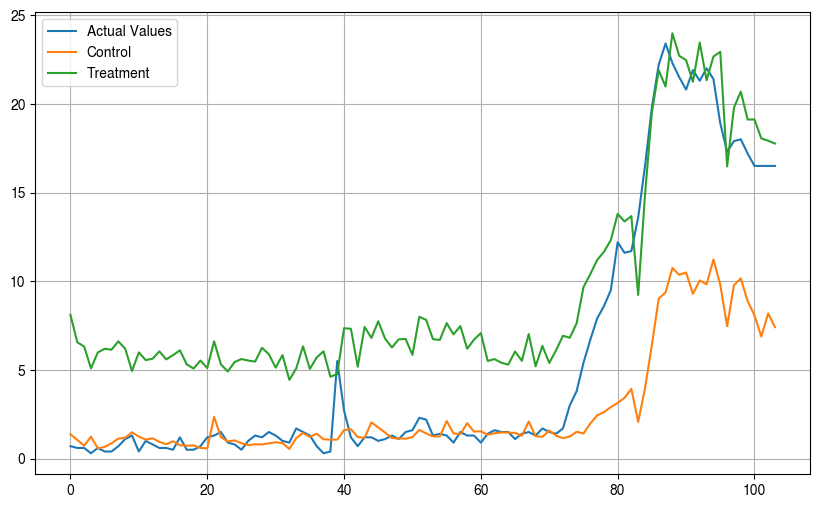

In [70]:
ex1 = df[df['id'] ==198]
ex1 = ex1.sort_values(by='date', ignore_index=True)
# ex1 = ex1[50:100]
plt.figure(figsize=(10, 6))
plt.plot(ex1['test'], label='Actual Values')
plt.plot(ex1['pred_c'], label='Control')
plt.plot(ex1['pred_t'], label='Treatment')
plt.title('')
plt.xlabel('')
plt.ylabel('')
plt.legend()
plt.grid()
plt.show()

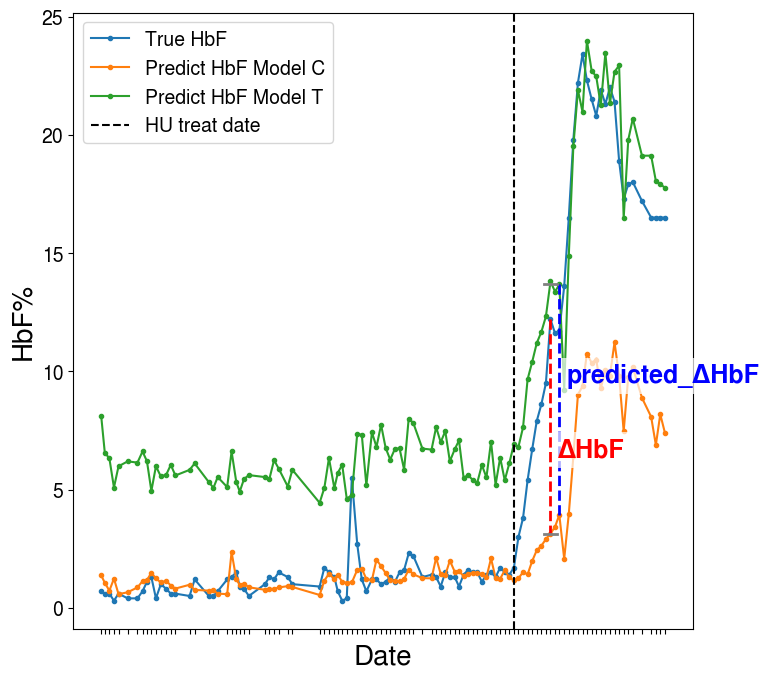

In [71]:
fig, ax=plt.subplots(figsize=(8,8))
# ex1.plot(x="dt", y=['test2','pred'],kind="line",ax=ax)
ax.plot(ex1['date'], ex1['test'], '.-', label='raw HbF')
ax.plot(ex1['date'], ex1['pred_c'], '.-', label='Predict HbF model C')
ax.plot(ex1['date'], ex1['pred_t'], '.-', label='Predict HbF Model T')

ax.set_ylabel('HbF%', fontsize=20)
ax.set_xlabel('Date',fontsize=20)
ax.axvline(x=ex1[ex1['hus']==1110]['date'],  color='k', linestyle='--',label='HU treatment')

x_val = ex1.loc[80, 'date']
x_val2 = ex1.loc[82, 'date']
y0 = ex1.loc[80, 'test']
y1= ex1.loc[80, 'pred_c']
y02 = ex1.loc[82, 'pred_c']
y2= ex1.loc[82, 'pred_t']

ax.plot([x_val, x_val], [y0, y1], color='red', linewidth=2, linestyle='--', label='deltaHbF')
ax.plot([x_val2, x_val2], [y02, y2], color='blue', linewidth=2, linestyle='--', label='predicted_deltaHbF')
bar_width = pd.Timedelta(days=80)  # Adjust the width to your desired bar length

ax.plot([x_val - bar_width/2, x_val + bar_width/2], [y1, y1], color='grey', linewidth=2)
ax.plot([x_val - bar_width/2, x_val + bar_width/2], [y2, y2], color='grey', linewidth=2)
# 4. Add text beside the line (midpoint)
y_mid = (y0 + y1) / 2
y_mid2 = (y02 + y2) / 2
ax.annotate(
    'ΔHbF', xy=(x_val, y_mid-1),
    xytext=(5, 0), textcoords='offset points',
    color='red', fontsize=18,
    va='center', ha='left', fontweight='bold',
    bbox=dict(facecolor='white', edgecolor='none', alpha=0.7)
)
ax.annotate(
    'predicted_ΔHbF', xy=(x_val2, y_mid2+1),
    xytext=(5, 0), textcoords='offset points',
    color='blue', fontsize=18,
    va='center', ha='left', fontweight='bold',
    bbox=dict(facecolor='white', edgecolor='none', alpha=0.7)
)

ax.set_xticks(list(ex1['date']),[], rotation=45, ha='right')
ax.tick_params(labelsize=14)
ax.legend(['True HbF', 'Predict HbF Model C','Predict HbF Model T', 'HU treat date'], fontsize=14)
# plt.grid(axis='y')
plt.savefig("../results/figures/summary/treat_control_example2.pdf")

In [72]:
df.to_pickle('../results/data/all_treat_control_prediction_loop_50.pkl')

(array([ 1.,  2.,  7.,  4., 12., 15., 16., 20., 17.,  6.]),
 array([0.80276018, 0.81218868, 0.82161719, 0.83104569, 0.84047419,
        0.84990269, 0.85933119, 0.86875969, 0.87818819, 0.88761669,
        0.8970452 ]),
 <BarContainer object of 10 artists>)

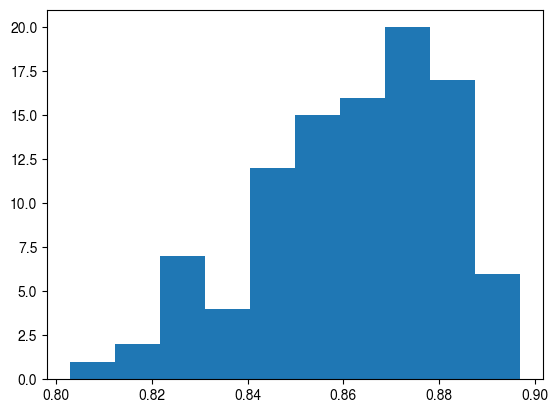

In [73]:
plt.hist(r2hu_list)

(array([13.,  9., 19., 16., 16.,  9., 11.,  4.,  1.,  2.]),
 array([0.75008112, 0.76353824, 0.77699535, 0.79045246, 0.80390958,
        0.81736669, 0.8308238 , 0.84428092, 0.85773803, 0.87119514,
        0.88465226]),
 <BarContainer object of 10 artists>)

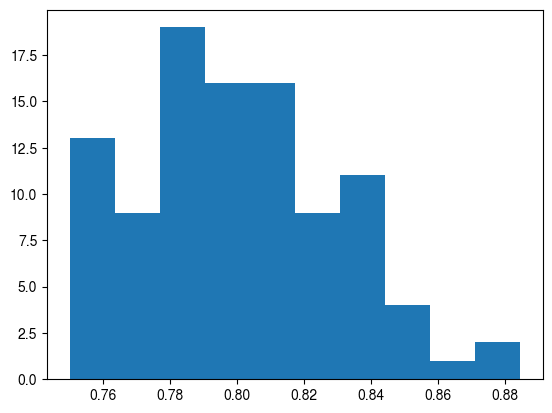

In [74]:
plt.hist(r2nohu_list)